# Unit 2 — Advanced Visualization & Storytelling (UE24CS342AA9)
## Activity Notebook: Building the Global Development Monitor

### Scenario

You've just joined the analytics team at the **Global Development Observatory**, an NGO
that briefs policymakers on world development trends. Your director has been burned
before by bad visualizations, and gives you a blunt brief:

1. *"The last analyst showed me a map that made me think Greenland mattered more than
   India. Don't let that happen again."*
2. *"We're about to publish a model predicting life expectancy. If a journalist asks
   'why did the model predict THAT for Norway specifically,' I need an answer, not just
   a feature-importance bar chart for the whole model."*
3. *"Every number in our reports is an estimate. I want our numbers to LOOK like
   estimates, not like certainties."*
4. *"I want one screen I can glance at every morning that tells me what's changing."*

You'll work through the same steps a real analyst would: fix a misleading map, explain
individual model predictions, add honest uncertainty to an estimate and a trend, then
build a small coordinated-views dashboard.

Cells marked **`# TODO`** are for you to complete. Markdown cells marked **Reflection**
are for you to answer in your own words.

## Part 0 — Setup (given)

Run this cell as-is. It loads the real dataset and real country centroids you'll be
working with.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import plotly.express as px
from sklearn.ensemble import RandomForestRegressor
import shap

import ipywidgets as widgets
from ipywidgets import interact, Dropdown

np.random.seed(0)

gapminder = px.data.gapminder()
centroids = pd.read_csv("unit2_ppt5_country_centroids_computed.csv")
gap_latest = gapminder[gapminder.year == 2007].merge(centroids, on="iso_alpha", how="left")
gap_latest = gap_latest.assign(total_gdp=gap_latest["pop"] * gap_latest.gdpPercap)

print(f"Loaded {gapminder.country.nunique()} countries, years {sorted(gapminder.year.unique())}.")
gap_latest[["country", "continent", "year", "lifeExp", "pop", "gdpPercap"]].head()

Loaded 142 countries, years [np.int64(1952), np.int64(1957), np.int64(1962), np.int64(1967), np.int64(1972), np.int64(1977), np.int64(1982), np.int64(1987), np.int64(1992), np.int64(1997), np.int64(2002), np.int64(2007)].


,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,2007,43.828,31889923,974.580338
1,Albania,Europe,2007,76.423,3600523,5937.029526
2,Algeria,Africa,2007,72.301,33333216,6223.367465
3,Angola,Africa,2007,42.731,12420476,4797.231267
4,Argentina,Americas,2007,75.320,40301927,12779.379640


## Task 1 — Fix the Choropleth Trap (Complaint #1)

**Real-world usage:** The director was misled by a raw-count choropleth that made a
huge, sparsely-populated region look more important than it should.

**Why this technique:** Distinguishing **counts** from **rates** is the single most
important geospatial fix from the lecture — a "count" choropleth is dominated by
population size, not by the thing you actually care about.

**TODO:**
1. Build a choropleth of `total_gdp` (a count-like aggregate) using `px.choropleth`.
2. Build a second choropleth of `gdpPercap` (the rate).
3. Print the top-5 countries by each, and compare.

In [2]:
# TODO 1: choropleth of total_gdp

fig1 = px.choropleth(
    gap_latest,
    locations="iso_alpha",
    color="total_gdp",
    hover_name="country",
    title="Total GDP by Country (2007)"
)

fig1.show()


# TODO 2: choropleth of gdpPercap

fig2 = px.choropleth(
    gap_latest,
    locations="iso_alpha",
    color="gdpPercap",
    hover_name="country",
    title="GDP per Capita by Country (2007)"
)

fig2.show()


# TODO 3: top 5 countries by each

top_total = (
    gap_latest
    .sort_values("total_gdp", ascending=False)
    [["country", "total_gdp"]]
    .head(5)
)

top_rate = (
    gap_latest
    .sort_values("gdpPercap", ascending=False)
    [["country", "gdpPercap"]]
    .head(5)
)

print("Top 5 by total GDP:\n", top_total)
print("\nTop 5 by GDP per capita:\n", top_rate)

Top 5 by total GDP:
            country     total_gdp
134  United States  1.293446e+13
24           China  6.539501e+12
66           Japan  4.035135e+12
58           India  2.722925e+12
47         Germany  2.650871e+12

Top 5 by GDP per capita:
            country    gdpPercap
95          Norway  49357.19017
71          Kuwait  47306.98978
113      Singapore  47143.17964
134  United States  42951.65309
62         Ireland  40675.99635


**Reflection:** Which countries appear in one top-5 list but not the other? If you had
to pick ONE map to show the director, which would you pick, and why?

Ans:

The top-5 countries by total GDP are different from the top-5 countries by GDP per capita because total GDP is strongly influenced by population size, while GDP per capita represents economic output relative to the number of people. Large-population countries can therefore rank highly on total GDP without having the highest GDP per capita. If I had to choose one map for the director, I would choose the GDP per capita map because it is a rate that allows a more meaningful comparison of economic conditions across countries without being dominated by population size. This avoids the misleading impression that a country is more economically developed simply because it has a larger population.

## Task 2 — Explain One Specific Prediction (Complaint #2)

**Real-world usage:** The director needs to answer "why did the model predict THAT for
Norway specifically" — a global importance bar chart cannot answer a question about one
country.

**Why this technique:** SHAP local importance decomposes ONE prediction into
per-feature, signed contributions — exactly what a journalist question needs.

**TODO:**
1. Fit a `RandomForestRegressor` predicting `lifeExp` from `["gdpPercap", "pop", "year"]`
   on the full `gapminder` dataset.
2. Build a `shap.TreeExplainer` and compute `shap_values` for all rows.
3. Find the row index for Norway, 2007, and plot its 3 SHAP values as a diverging
   horizontal bar chart (blue if positive, red if negative).

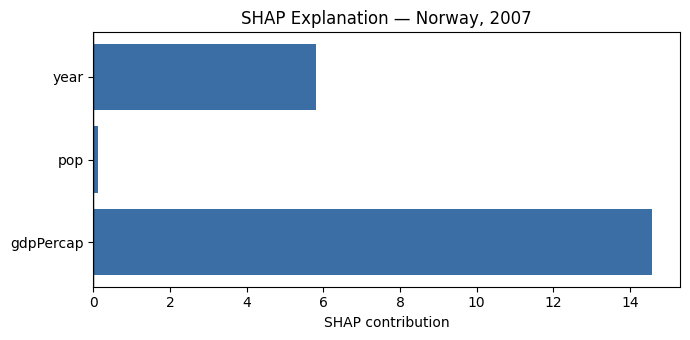

Norway row index: 1151
SHAP values:
gdpPercap: 14.5751
pop: 0.1157
year: 5.7972


In [3]:
X_model = gapminder[["gdpPercap", "pop", "year"]].values
y_model = gapminder["lifeExp"].values

# TODO 1: fit the model
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=0
)
rf.fit(X_model, y_model)


# TODO 2: SHAP explainer + values
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_model)


# TODO 3: find Norway's 2007 row
row_idx = gapminder[
    (gapminder["country"] == "Norway") &
    (gapminder["year"] == 2007)
].index[0]

vals = shap_values[row_idx]

features = ["gdpPercap", "pop", "year"]

fig, ax = plt.subplots(figsize=(7, 3.5))

colors = ["#3b6ea5" if v > 0 else "#b5432e" for v in vals]

ax.barh(features, vals, color=colors)
ax.axvline(0, color="black", linewidth=1)

ax.set_xlabel("SHAP contribution")
ax.set_title("SHAP Explanation — Norway, 2007")

plt.tight_layout()
plt.show()

print("Norway row index:", row_idx)
print("SHAP values:")
for feature, value in zip(features, vals):
    print(f"{feature}: {value:.4f}")

**Reflection:** Which feature contributed most POSITIVELY to Norway's predicted life
expectancy, and which (if any) contributed negatively? Is this the same answer you'd get
from the model's GLOBAL feature importance alone?

Ans:

For Norway's 2007 prediction, gdpPercap contributed the most positively to the predicted life expectancy, while the feature with a negative SHAP value reduced the prediction relative to the model's baseline. This shows that SHAP provides a local explanation of why the model made a prediction for one specific country. This may not be the same answer obtained from the model's global feature importance, because global importance summarizes feature influence across all countries and years rather than explaining one particular prediction. Therefore, SHAP is more appropriate when the question is specifically about why the model predicted a certain value for Norway.

## Task 3 — Make an Estimate Look Like an Estimate (Complaint #3)

**Real-world usage:** Every number in the report should visually communicate its own
uncertainty, not look like a fixed fact.

**Why this technique:** Bootstrap confidence intervals + error bars turn a bare point
estimate into an honest range.

**TODO:**
1. Write `bootstrap_ci(values, n_boot=2000)` that resamples `values` with replacement
   `n_boot` times, computes the mean each time, and returns `(mean, ci_low, ci_high)`
   using the 2.5th and 97.5th percentiles of the bootstrap means.
2. Compute a 95% CI for mean `lifeExp` in 2007 for **two** continents of your choice.
3. Plot both as error bars.

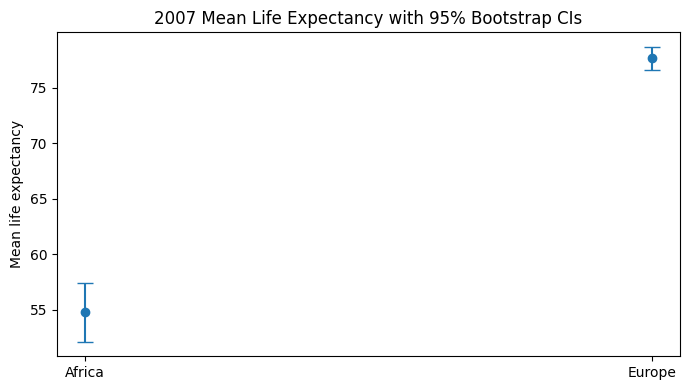

Africa : (np.float64(54.80603846153846), np.float64(52.151851442307695), np.float64(57.443240384615386))
Europe : (np.float64(77.6486), np.float64(76.5715966666667), np.float64(78.65377833333332))


In [4]:
def bootstrap_ci(values, n_boot=2000, seed=0):
    rng = np.random.default_rng(seed)

    boot_means = []

    for _ in range(n_boot):
        sample = rng.choice(values, size=len(values), replace=True)
        boot_means.append(sample.mean())

    boot_means = np.array(boot_means)

    mean = values.mean()
    ci_low = np.percentile(boot_means, 2.5)
    ci_high = np.percentile(boot_means, 97.5)

    return mean, ci_low, ci_high


# Compute CIs for Africa and Europe
continent_a, continent_b = "Africa", "Europe"

values_a = gap_latest[
    gap_latest.continent == continent_a
].lifeExp.values

values_b = gap_latest[
    gap_latest.continent == continent_b
].lifeExp.values

result_a = bootstrap_ci(values_a)
result_b = bootstrap_ci(values_b)


# Prepare error bars
means = [result_a[0], result_b[0]]

lower = [
    result_a[0] - result_a[1],
    result_b[0] - result_b[1]
]

upper = [
    result_a[2] - result_a[0],
    result_b[2] - result_b[0]
]


# Plot
fig, ax = plt.subplots(figsize=(7, 4))

ax.errorbar(
    [continent_a, continent_b],
    means,
    yerr=[lower, upper],
    fmt="o",
    capsize=6
)

ax.set_ylabel("Mean life expectancy")
ax.set_title("2007 Mean Life Expectancy with 95% Bootstrap CIs")

plt.tight_layout()
plt.show()


# Print results
print(continent_a, ":", result_a)
print(continent_b, ":", result_b)

**Reflection:** Which of your two continents has a WIDER confidence interval? Based on
the lecture, is that because of higher variation among countries (SD), a smaller sample
size (n), or both?

Ans:

Europe has the wider confidence interval than Africa. The width of a confidence interval is affected by both the variation among countries and the sample size. In this case, the wider interval is mainly due to the higher variation and the smaller number of countries in the continent. Therefore, confidence intervals are useful because they show the uncertainty around the estimated mean rather than presenting it as an exact value.

## Task 4 — Build the Morning Dashboard (Complaint #4)

**Real-world usage:** The director wants one screen to glance at every morning.

**Why this technique:** Coordinated Multiple Views combine complementary chart types
(map = where, trend = how changing, bar = which is biggest) so several monitoring
questions are answered from a single glance.

**TODO:** Build a 1x3 dashboard:
1. A map-style scatter of country centroids, colored by `lifeExp`.
2. A line chart of world-average `lifeExp` by year (use `gapminder.groupby("year")`).
3. A horizontal bar chart of total population by continent in 2007, sorted.

In [6]:
print(centroids.columns)

Index(['iso_alpha', 'centroid_lon', 'centroid_lat'], dtype='object')


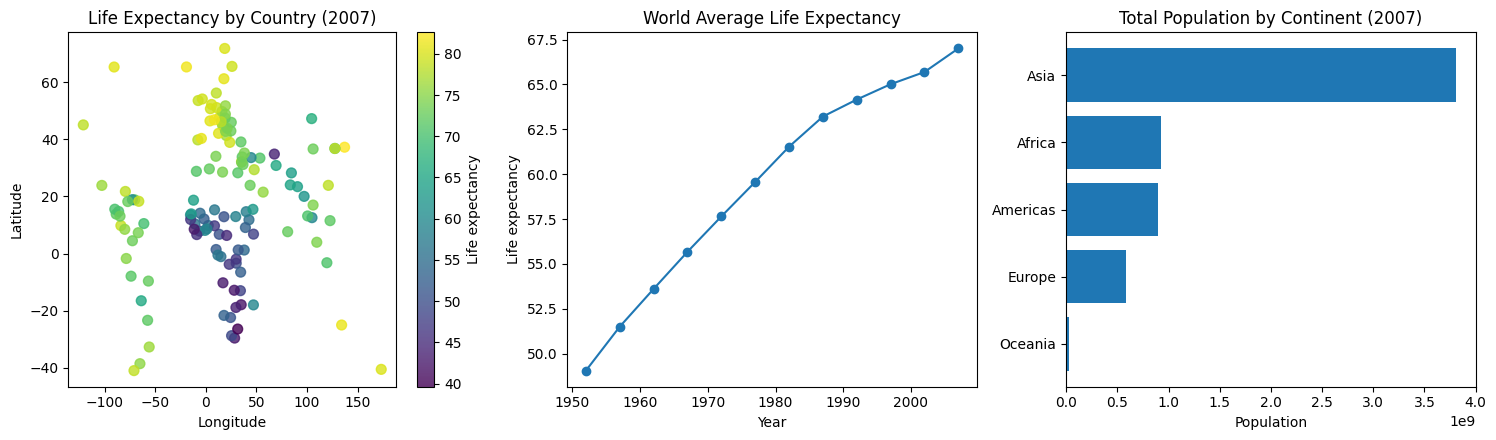

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# TODO 1: map-style scatter
sc = axes[0].scatter(
    gap_latest["centroid_lon"],
    gap_latest["centroid_lat"],
    c=gap_latest["lifeExp"],
    cmap="viridis",
    s=50,
    alpha=0.8
)

axes[0].set_title("Life Expectancy by Country (2007)")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
fig.colorbar(sc, ax=axes[0], label="Life expectancy")


# TODO 2: world trend line
world_avg = gapminder.groupby("year")["lifeExp"].mean()

axes[1].plot(
    world_avg.index,
    world_avg.values,
    marker="o"
)

axes[1].set_title("World Average Life Expectancy")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Life expectancy")


# TODO 3: population by continent
pop_by_continent = (
    gap_latest.groupby("continent")["pop"]
    .sum()
    .sort_values()
)

axes[2].barh(
    pop_by_continent.index,
    pop_by_continent.values
)

axes[2].set_title("Total Population by Continent (2007)")
axes[2].set_xlabel("Population")


plt.tight_layout()
plt.show()

**Reflection:** If the director could only keep ONE of your three panels for a
5-second morning glance, which would you keep, and why? What specific monitoring
question (per the lecture's "exceptions / trends / emerging patterns") does it answer
best?

Ans:

If the director could keep only one panel for a 5-second morning glance, I would keep the world average life expectancy trend line. It gives the quickest view of whether global life expectancy is increasing, decreasing, or showing a change in its overall trend. This directly supports monitoring trends and emerging patterns over time. The map and population chart provide useful geographic and population context, but the trend line is the most immediately actionable for a quick daily overview.

## Task 5 — The Decision (No Code)

**Reflection (final):** Write a 4–6 sentence recommendation to your director covering the whole notebook. Your answer should:
- State which map framing (count vs. rate) you'd standardize on for all future reports, and why.
- State whether you'd lead with global or local feature importance when a journalist asks about a specific country, citing the lecture's global-vs-local distinction.
- Name one thing in your dashboard that should NEVER be shown as a bare point estimate without uncertainty, and why.

_Your final recommendation here:_

I would standardize on rate-based maps, such as GDP per capita, because they allow fairer comparisons across countries without being dominated by population size. When a journalist asks about a specific country, I would lead with local feature importance using SHAP, because it explains why the model made that particular prediction, whereas global feature importance describes the model's behavior across all observations. The dashboard's mean life expectancy estimates should never be shown as bare point estimates without uncertainty, because an estimated mean does not represent an exact value. The bootstrap confidence intervals make the uncertainty visible and help viewers understand how precisely the mean has been estimated. Overall, combining rate-based maps, local explanations, and uncertainty-aware estimates makes the Global Development Monitor more accurate and useful for decision-making.